In [ ]:
import os
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name != "TMDB":
    candidate = project_root / "TMDB"
    if candidate.exists():
        project_root = candidate

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Working directory: {Path.cwd()}")

Working directory: c:\Users\mbarn\amalitechprojects\TMDB


In [ ]:
import pandas as pd
from IPython.display import Image, display

from api.api import TMDB
from processing.clean_movies import clean_movies, DROP_COLS, FINAL_COLUMNS
from analysis.kpi_analysis import compute_profit, search_movies, top_franchises
from visualization.plots import (
    plot_revenue_vs_budget,
    plot_roi_by_genre,
    plot_popularity_vs_rating,
    plot_yearly_revenue_trends,
    plot_franchise_vs_standalone,
)

## Step 1: Fetch Movie Data from API

Reference: TMDB API docs https://developer.themoviedb.org/reference/intro/getting-started

Goal: fetch the required movie IDs and store the response as a Pandas DataFrame.

In [ ]:
movie_ids = [
    0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259,
    99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513,
]

tmdb = TMDB()
movies_payload = await tmdb.get_movies_batch_async(movie_ids, max_concurrent=4)
raw_df = pd.json_normalize(movies_payload, max_level=0)

print(f"Requested IDs: {len(movie_ids)}")
print(f"Fetched records: {len(raw_df)}")
display(raw_df.head(3))

ERROR:api.api:Error fetching movie 299534: 
ERROR:api.api:Error fetching movie 0: 
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299534?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 299534 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299536?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 299536 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/19995?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 19995 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/140607?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 140607 with credits
ERROR:api.api:Error fetching movie 0: 
INFO:httpx:H

Single movie keys: None
Async batch size: 4
Sync batch size: 4


## Step 2: Data Cleaning and Preprocessing

### 2.1 Data Preparation and Cleaning

- Drop irrelevant columns
- Evaluate JSON-like columns
- Extract collection/genres/languages/countries/companies
- Convert datatypes and handle missing/incorrect values

In [ ]:
print("Columns before cleaning:", len(raw_df.columns))
print("Rows before cleaning:", len(raw_df))

preview_cols = [c for c in ["id", "title", "genres", "belongs_to_collection", "production_companies", "production_countries", "spoken_languages"] if c in raw_df.columns]
display(raw_df[preview_cols].head(3))

clean_df = clean_movies(raw_df)
print("Rows after cleaning:", len(clean_df))
print("Columns after cleaning:", len(clean_df.columns))
display(clean_df.head(3))

ERROR:api.api:Error fetching movie 0: 
ERROR:api.api:Error fetching movie 299536: 
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/299534?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
ERROR:api.api:Error fetching movie 597: 
INFO:api.api:Fetched movie 299534 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/19995?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 19995 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/140607?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:api.api:Fetched movie 140607 with credits
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3/movie/135397?api_key=8b3fa69ac4f1756c2aaf5fac9abffa3f&language=en-US&append_to_response=credits "HTTP/2 200 OK"
INFO:httpx:HTTP Request: GET https://api.themoviedb.org/3

genres
Action|Adventure|Science Fiction             3
Adventure|Action|Science Fiction             2
Action|Adventure|Science Fiction|Thriller    2
Adventure|Science Fiction|Action             1
Adventure|Drama|Family|Animation             1
Name: count, dtype: int64
raw_df shape: (16, 27)
clean_df shape: (16, 22)
kpi_df shape: (16, 24)


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729


### 2.2 Inspect Extracted Columns for Anomalies

In [ ]:
inspect_cols = [
    "belongs_to_collection",
    "genres",
    "spoken_languages",
    "production_countries",
    "production_companies",
]

for col in inspect_cols:
    if col in clean_df.columns:
        print(f"\n{col} top values:")
        print(clean_df[col].value_counts(dropna=False).head(10))

### 2.3 Data Quality Checks (Missing and Incorrect Values)

In [ ]:
raw_quality = pd.DataFrame({
    "budget_zero": [int((pd.to_numeric(raw_df.get("budget"), errors="coerce") == 0).sum()) if "budget" in raw_df else 0],
    "revenue_zero": [int((pd.to_numeric(raw_df.get("revenue"), errors="coerce") == 0).sum()) if "revenue" in raw_df else 0],
    "runtime_zero": [int((pd.to_numeric(raw_df.get("runtime"), errors="coerce") == 0).sum()) if "runtime" in raw_df else 0],
    "vote_count_zero": [int((pd.to_numeric(raw_df.get("vote_count"), errors="coerce") == 0).sum()) if "vote_count" in raw_df else 0],
})

clean_quality = pd.DataFrame({
    "missing_budget_musd": [int(clean_df["budget_musd"].isna().sum())],
    "missing_revenue_musd": [int(clean_df["revenue_musd"].isna().sum())],
    "missing_runtime": [int(clean_df["runtime"].isna().sum())],
    "missing_vote_count": [int(clean_df["vote_count"].isna().sum())],
})

print("Raw quality indicators:")
display(raw_quality)
print("Cleaned quality indicators:")
display(clean_quality)

### 2.4 Finalize DataFrame (Schema, Order, Index)

In [ ]:
print("Final columns in expected order:", clean_df.columns.tolist() == FINAL_COLUMNS)
print("Final shape:", clean_df.shape)
print("Rows with unknown id/title:", int(clean_df[["id", "title"]].isna().any(axis=1).sum()))
print("Any status column left:", "status" in clean_df.columns)
display(clean_df.head(3))

## Step 3: KPI Implementation and Analysis

### 3.1 Build KPI Dataset and Ranking UDF

In [ ]:
kpi_df = compute_profit(clean_df).copy()

def rank_kpi(df: pd.DataFrame, metric: str, top_n: int = 5, ascending: bool = False) -> pd.DataFrame:
    cols = ["id", "title", metric]
    available = [c for c in cols if c in df.columns]
    return df.sort_values(metric, ascending=ascending).head(top_n)[available]

rankings = {
    "Highest Revenue": rank_kpi(kpi_df, "revenue_musd", top_n=5, ascending=False),
    "Highest Budget": rank_kpi(kpi_df, "budget_musd", top_n=5, ascending=False),
    "Highest Profit": rank_kpi(kpi_df, "profit_musd", top_n=5, ascending=False),
    "Lowest Profit": rank_kpi(kpi_df, "profit_musd", top_n=5, ascending=True),
    "Highest ROI (budget >= 10M)": rank_kpi(kpi_df[kpi_df["budget_musd"] >= 10], "roi", top_n=5, ascending=False),
    "Lowest ROI (budget >= 10M)": rank_kpi(kpi_df[kpi_df["budget_musd"] >= 10], "roi", top_n=5, ascending=True),
    "Most Voted": rank_kpi(kpi_df, "vote_count", top_n=5, ascending=False),
    "Highest Rated (vote_count >= 10)": rank_kpi(kpi_df[kpi_df["vote_count"] >= 10], "vote_average", top_n=5, ascending=False),
    "Lowest Rated (vote_count >= 10)": rank_kpi(kpi_df[kpi_df["vote_count"] >= 10], "vote_average", top_n=5, ascending=True),
    "Most Popular": rank_kpi(kpi_df, "popularity", top_n=5, ascending=False),
}

for name, frame in rankings.items():
    print(f"\n=== {name} ===")
    display(frame)


=== filter_votes ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729
3,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428,1521.537444,10.143583
4,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,52,1402.020819,5.392388



=== top_revenue ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,265,1823.223624,7.441729
3,135397,Jurassic World,The park is open.,2015-06-06,Action|Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,428,1521.537444,10.143583
4,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,...,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,52,1402.020819,5.392388



=== top_budget ===


...

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
5,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|हिन्दी|Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642,1298.815515,5.903707
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
10,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Adventure|Action|Science Fiction,Star Wars Collection,en,300.0,1332.698830,Lucasfilm Ltd.,...,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,111,Rian Johnson,199,1032.698830,3.442329
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
13,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Animation|Family|Adventure|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck,286,1124.219009,7.494793



=== search_movies ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Anthony Russo,610,2443.439100,6.863593
5,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|हिन्दी|Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,642,1298.815515,5.903707
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,996,2686.706026,11.336312
15,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,260,1043.225667,5.216128
8,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,135,"King T'Challa returns home to the reclusive, t...",English|한국어/조선말|Kiswahili|,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,66,Ryan Coogler,570,1149.926083,5.749630



=== search_movies Bruce Willis ===


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


### 3.2 Advanced Filtering and Search Queries

In [ ]:
from analysis.kpi_analysis import search_movies

search_1 = search_movies(
    kpi_df,
    genre=["Science Fiction", "Action"],
    actors="Bruce Willis",
    sort_by="vote_average",
    ascending=False,
 )

search_2 = search_movies(
    kpi_df,
    actors="Uma Thurman",
    director="Quentin Tarantino",
    sort_by="runtime",
    ascending=True,
 )

print("Search 1: Best-rated Science Fiction/Action movies starring Bruce Willis")
display(search_1[["title", "vote_average", "genres", "cast"]].head(10))

print("Search 2: Movies starring Uma Thurman directed by Quentin Tarantino")
display(search_2[["title", "runtime", "director", "cast"]].head(10))

### 3.3 Franchise vs Standalone Performance

In [ ]:
franchise_perf = (
    kpi_df.assign(franchise_flag=kpi_df["belongs_to_collection"].notna())
    .groupby("franchise_flag")
    .agg(
        mean_revenue=("revenue_musd", "mean"),
        median_roi=("roi", "median"),
        mean_budget=("budget_musd", "mean"),
        mean_popularity=("popularity", "mean"),
        mean_rating=("vote_average", "mean"),
    )
    .rename(index={True: "Franchise", False: "Standalone"})
    .reset_index(names="group")
)

display(franchise_perf)

### 3.4 Most Successful Franchises and Directors

In [ ]:
top_franchise_df = top_franchises(kpi_df, top_n=10)
display(top_franchise_df)

top_directors_df = (
    kpi_df.dropna(subset=["director"])
    .groupby("director", as_index=False)
    .agg(
        total_movies=("id", "count"),
        total_revenue=("revenue_musd", "sum"),
        mean_rating=("vote_average", "mean"),
    )
    .sort_values(by=["total_revenue", "mean_rating"], ascending=[False, False])
    .head(10)
)

display(top_directors_df)

## Step 4: Data Visualization

Use Pandas + Matplotlib outputs generated by project plotting helpers.


Generated: reports/figures/roi_by_genre.png


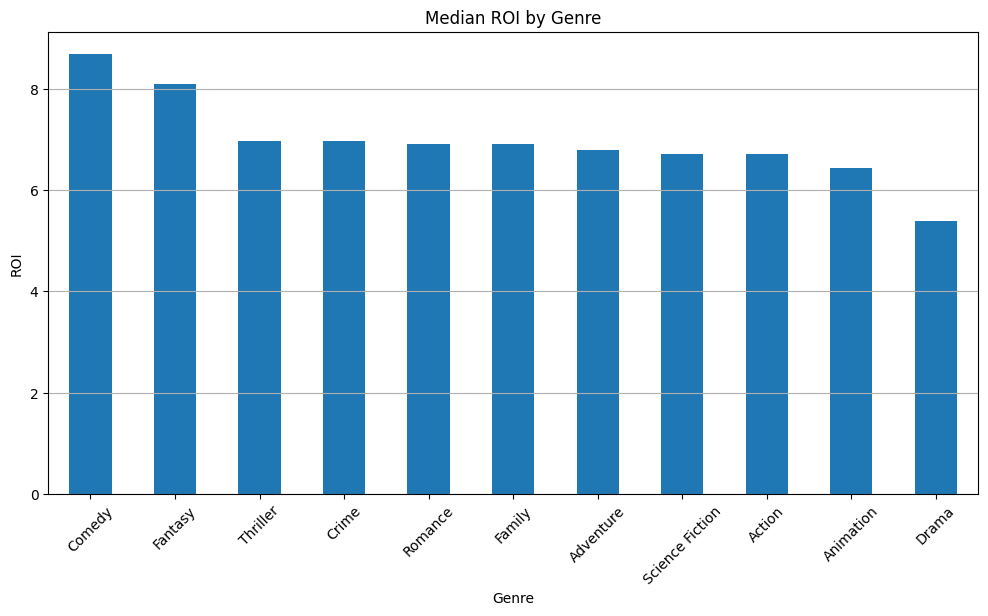


Generated: reports/figures/revenue_vs_budget.png


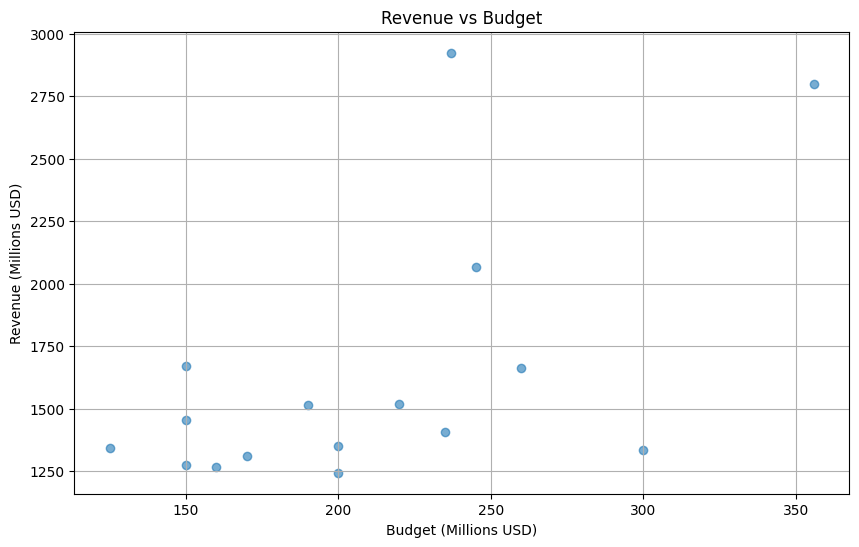


Generated: reports/figures/popularity_vs_rating.png


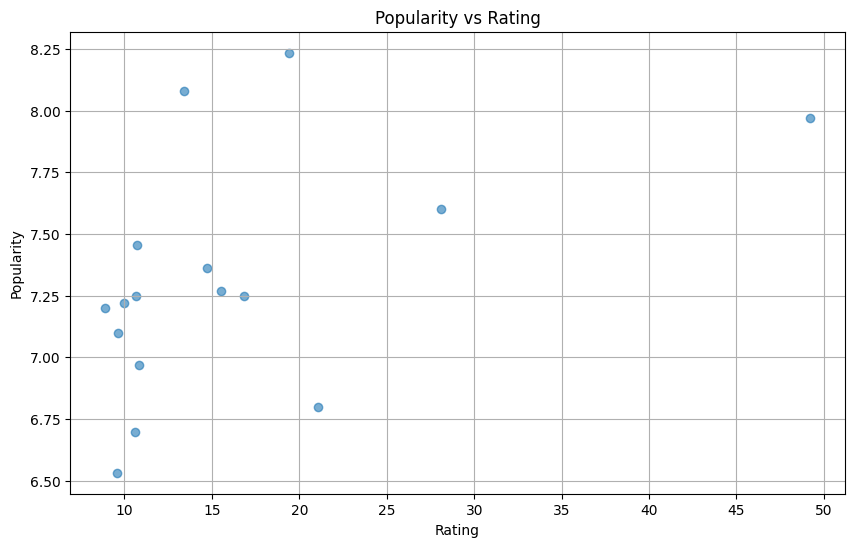


Generated: reports/figures/yearly_revenue_trends.png


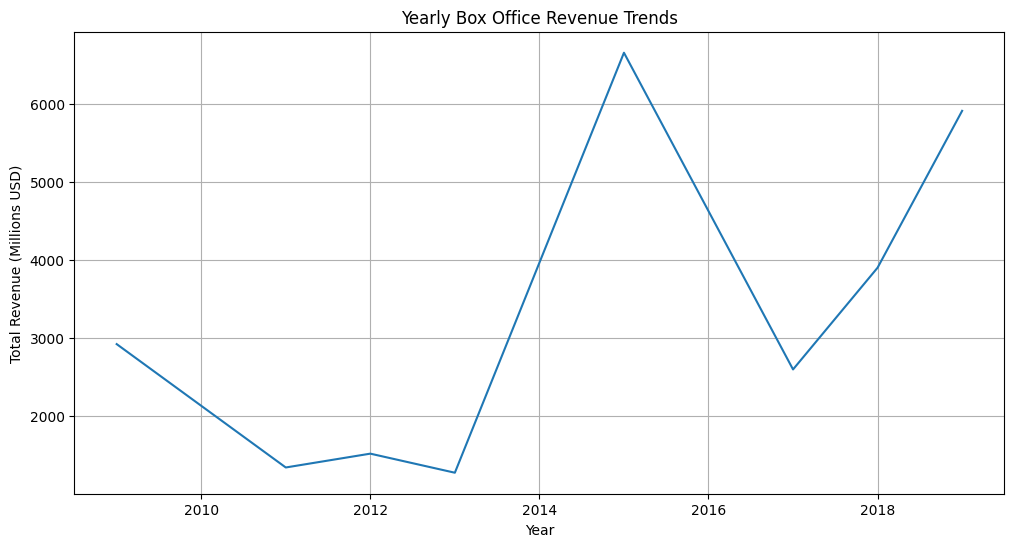


Generated: reports/figures/franchise_vs_standalone.png


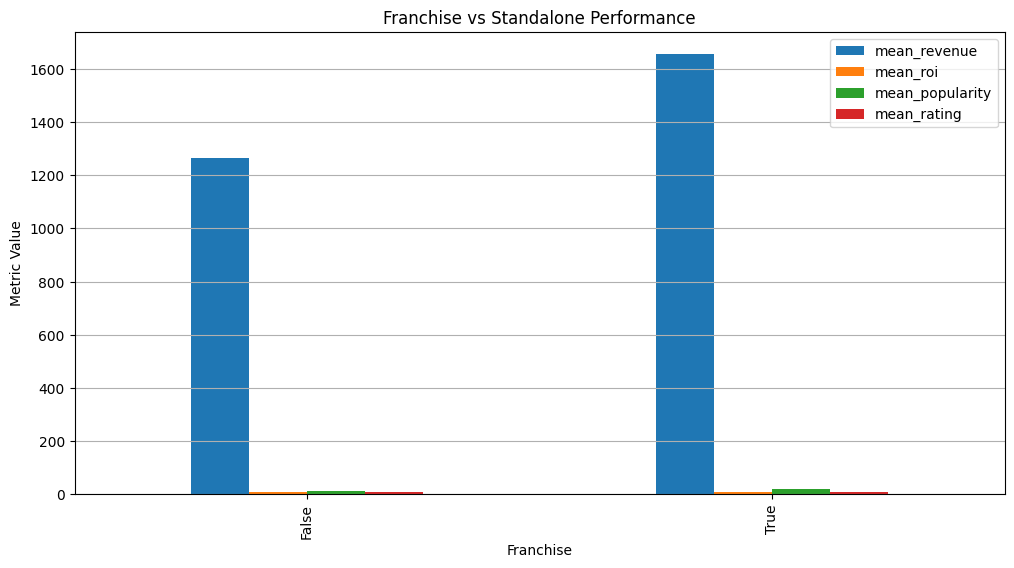

In [ ]:
plot_roi_by_genre(kpi_df)
plot_revenue_vs_budget(kpi_df)
plot_popularity_vs_rating(kpi_df)
plot_yearly_revenue_trends(kpi_df)
plot_franchise_vs_standalone(kpi_df)

figure_files = [
    "reports/figures/roi_by_genre.png",
    "reports/figures/revenue_vs_budget.png",
    "reports/figures/popularity_vs_rating.png",
    "reports/figures/yearly_revenue_trends.png",
    "reports/figures/franchise_vs_standalone.png",
]

print("Generated figure files:")
for fig in figure_files:
    print(fig)

### Display Generated Figures

In [ ]:
for fig in figure_files:
    display(Image(filename=fig))